# QVolution - QHackathon: Harmonic Oscillator Solver

## 1. Problem Formulation
**Standard Linear Differential Equation (LDE) Problem:**
$$ \frac{dx(t)}{dt} = \mathcal{M}x(t) + b \quad \text{(First order)} $$

**Competition Problem:**
$$ y'' + \omega^2 y = 0, \quad \text{where } \omega=1 $$
**Initial Conditions:** $y(0)=1, \quad y'(0)=1$.

**Vectorization:**
To convert the second-order equation to first-order, let:
$$ X = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} y \\ y' \end{bmatrix} $$

From the differential equation (since $\omega=1, y'' = -y$):
1. $\frac{dx_2}{dt} = y'' = -y = -x_1$
2. $\frac{dx_1}{dt} = y' = x_2$

Thus, the system becomes:
$$ \frac{dX}{dt} = \begin{bmatrix} x_1' \\ x_2' \end{bmatrix} = \begin{bmatrix} x_2 \\ -x_1 \end{bmatrix} $$

---

## 2. Finding Matrix $\mathcal{M}$
We need a relation $\mathcal{M}X = \frac{dX}{dt}$.
$$ \mathcal{M} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} x_2 \\ -x_1 \end{bmatrix} $$

Since the elements are swapped and there is a sign change, $\mathcal{M}$ acts like a bit-flip with a phase.
$$ \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} x_2 \\ -x_1 \end{bmatrix} $$

Thus:
$$ \mathcal{M} = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix}, \quad b = 0 $$

---

## 3. Unitary Analysis
For quantum computers, we prefer unitary operators. Notice the similarity to the Pauli-Y matrix:
$$ Y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix} $$

Let's calculate $iY$:
$$ iY = i \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix} = \begin{bmatrix} 0 & -i^2 \\ i^2 & 0 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} = \mathcal{M} $$

**Conclusion:** Since $Y$ is unitary, $\mathcal{M} = iY$ is also unitary (preserving norm).
The solution is of the form:
$$ X(t) = \exp(\mathcal{M}t)X(0) $$

We aim to create an operator $U$ such that $U|X(0)\rangle = \exp(\mathcal{M}t)|X(0)\rangle$.

---

## 4. Algorithm: Taylor Expansion
Using the Taylor series to approximate the exponential:
$$ X(t) \approx \sum_{m=0}^{k} \frac{(\mathcal{M}t)^m}{m!} X(0)  $$
*(Note: The second term involving $b$ vanishes because $b=0$)*.

**Powers of $\mathcal{M}$ (Cyclic Property):**
Since $\mathcal{M} = iY$:
*   $m=0: \quad \mathcal{M}^0 = I$
*   $m=1: \quad \mathcal{M}^1 = iY$
*   $m=2: \quad \mathcal{M}^2 = (iY)^2 = i^2 Y^2 = -I$
*   $m=3: \quad \mathcal{M}^3 = -iY$
*   $m=4: \quad \mathcal{M}^4 = I$

The cycle repeats every 4 steps.

Expanding the summation,
$$
X(t) \approx \left( I \cdot \frac{t^0}{0!} + iY \frac{t^1}{1!} + (-I)\frac{t^2}{2!} + (-iY)\frac{t^3}{3!} + I \cdot \frac{t^4}{4!} + iY \frac{t^5}{5!} + (-I)\frac{t^6}{6!} + (-iY)\frac{t^7}{7!} + \dots \right) X(0)
$$
we can see a pattern.

**Grouping Terms:**
$$
X(t) \approx \left[ \underbrace{\left( \frac{t^0}{0!} - \frac{t^2}{2!} + \frac{t^4}{4!} - \frac{t^6}{6!} + \dots \right)}_{\cos t} + \underbrace{\left( \frac{t^1}{1!} - \frac{t^3}{3!} + \frac{t^5}{5!} - \frac{t^7}{7!} + \dots \right)}_{\sin t} iY \right] X(0)
$$
So, simply:
$$
X(t) \approx (\cos t \cdot I + i \sin t \cdot Y) X(0)
$$
*Observation:* This looks like a rotation gate $R_y(\theta) = \cos\frac{\theta}{2}I - i\sin\frac{\theta}{2}Y$. More specifically, in our case the rotation would be in the reverse direction with $\theta = 2t$.

---

## 5. Circuit Implementation Strategy

### Resources
*   **Work Qubits:** $\log_2(N) = \log_2(2) = 1$ qubit.
*   **Ancilla Qubits:** Depends on order $k$. For $k=3$ (covering $I, iY, -I, -iY$), we need 2 qubits ($2^2=4$ states).

### The Circuit Design (LCU Method)

**Step 1: Initialize**
*   **Work Qubit:** $|0\rangle \xrightarrow{H} \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$.
    *   This corresponds to $y=1, y'=1$.
*   **Ancillas:** $|00\rangle$.

**Step 2: Encoding ($V$ Box / `inplace_prepare_state`)**
We prepare the ancillas with the Taylor coefficients and the phases ($1, i, -1, -i$) absorbed into the amplitudes:
$$ \text{Amplitudes} \propto \left[ \frac{t^0}{0!}, \quad i\frac{t^1}{1!}, \quad -\frac{t^2}{2!}, \quad -i\frac{t^3}{3!} \right] $$

**Step 3: Entanglement (Controlled Operations)**
Based on the cycle ($I, Y, I, Y \dots$ ignoring phases which are now in ancilla):
*   $k=0 (00) \to I$
*   $k=1 (01) \to Y$
*   $k=2 (10) \to I$
*   $k=3 (11) \to Y$
*   **Logic:** Apply $Y$ only when the first ancilla qubit (LSB) is $|1\rangle$.

**Step 4: Decoding ($V^\dagger$)**
Apply `adjoint(inplace_prepare_state)`.

---

## 6. Measurement and Post-Processing

**Sanity Check:**
After decoding, the Ancilla qubits **must** be measured as $|00\rangle$ for the run to be valid.

**Energy Calculation:**
For the harmonic oscillator ($\omega=1, m=1$), energy is conserved.
$$ E_{total} = \frac{1}{2}y(0)^2 + \frac{1}{2}y'(0)^2 = \frac{1}{2}(1) + \frac{1}{2}(1) = 1 $$

Measuring the Work Qubit:
*   Outcome $|0\rangle$ with prob $\alpha^2 \implies$ **Potential Energy (P.E.)**
*   Outcome $|1\rangle$ with prob $\beta^2 \implies$ **Kinetic Energy (K.E.)**

$$ P.E. = \alpha^2 \times E_{total} = \alpha^2 $$
$$ K.E. = \beta^2 \times E_{total} = \beta^2 $$

## Necessary Installations and imports

In [ ]:
!pip install classiq


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import classiq
classiq.authenticate()

c:\Users\natha\classiq_env\Lib\site-packages\classiq\_internals\authentication\token_manager.py:113: UserWarning: Device is already registered.
Generating a new refresh token should only be done if the current refresh token is compromised.
To do so, set the overwrite parameter to true
  warnings.warn(


In [ ]:
from classiq import *
from classiq.execution import ExecutionPreferences
from classiq import set_execution_preferences
import numpy as np
import math
import matplotlib.pyplot as plt

## Circuit implementation for k=3

In [ ]:
def get_ho_circuit(time,error_bound):
  @qfunc
  def main(work_q: Output[QBit],anc_q: Output[QArray[QBit]])->None:
    # allocate one work and two ancilla qubits
    allocate(1,work_q)
    allocate(2,anc_q)

    # initialize the work qubit to |+> state
    H(work_q)

    # the prababilities
    raw_probs = [1.0, time, (time**2)/2, (time**3)/6]
    norm = sum(raw_probs)
    probs = [p/norm for p in raw_probs]

    # prepare the state i.e. encode
    inplace_prepare_state(probabilities=probs,bound=error_bound,target=anc_q)
    # state |00>: m=0: term = I: do nothing

    # state |01>: m=1: term = iY: apply RY(-pi)
    within_apply(
            lambda: X(anc_q[1]),
            lambda: control(anc_q, lambda: RY(-np.pi, work_q)) # iY
        )
    # state |10>: m=2: term = -I: apply RZ(2*pi)
    within_apply(
            lambda: X(anc_q[0]),
            lambda: control(anc_q, lambda: RZ(2*np.pi, work_q)) # -I
        )
    # state |11>: m=3: term = -iY: apply RY(pi)
    control(anc_q, lambda: RY(np.pi, work_q)) # -iY

    # decode
    invert(lambda: inplace_prepare_state(probs,bound=error_bound,target=anc_q))

  return create_model(main)

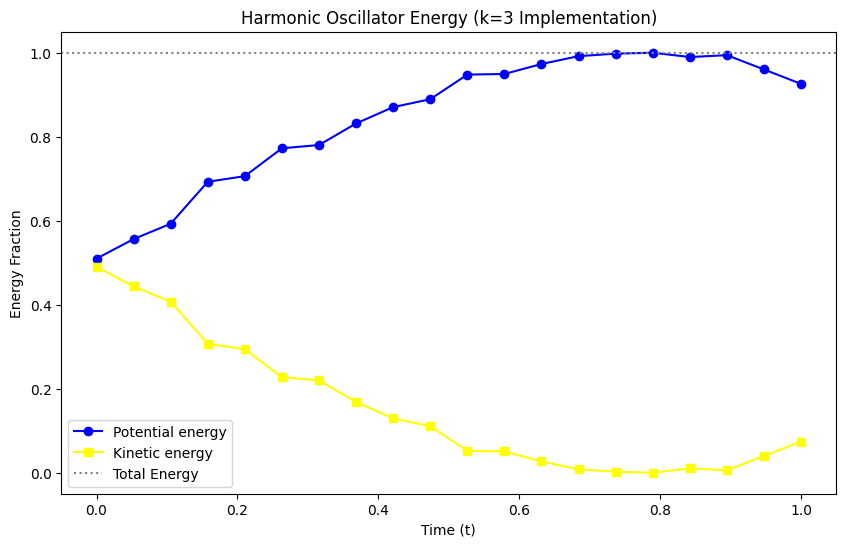

In [ ]:
# create an array of 20 time points from 0 to 1
ts=np.linspace(0,1,20)

# fixed bound parameter
fixed_bound = 0.01

# lists to store measurement counts for potential and kinetic energy
counts_pe = []
counts_ke = []

# loop over each time point
for t in ts:
  # HO quantum circuit at time t with fixed bound
  model = get_ho_circuit(t,fixed_bound)

  # synthesize circuit with Classiq engine to recieve quantum program
  qprog = synthesize(model)

  # execute quantum program
  job = execute(qprog)

  # get measurement counts from the result
  counts = job.result()[0].value.counts

  # get counts for potential ("000") and kinetic ("001") energies
  c000 = counts.get("000", 0)
  c001 = counts.get("001", 0)

  # store counts
  counts_pe.append(c000)
  counts_ke.append(c001)

# compute total number of shots for each time point
total_shots = [p+k for (p,k) in zip(counts_pe,counts_ke)]

# compute probabilities for PE and KE while avoiding dividing by zero if total_shots == 0
prob_pe = [p/t if t > 0 else 0 for p, t in zip(counts_pe, total_shots)]
prob_ke = [k/t if t > 0 else 0 for k, t in zip(counts_ke, total_shots)]

# plot the energy fractions as a function of time
plt.figure(figsize=(10,6))
plt.plot(ts, prob_pe, 'o-', label='Potential energy', color='blue')
plt.plot(ts, prob_ke, 's-', label='Kinetic energy', color='yellow')
plt.axhline(y=1.0, color='gray', linestyle=':', label='Total Energy')

plt.title(f'Harmonic Oscillator Energy (k=3 Implementation)')
plt.xlabel('Time (t)')
plt.ylabel('Energy Fraction')
plt.legend()
plt.show()

Starting accuracy analysis at t=1 
Exact value of potential energy fracton:  0.9546
-------------------------------------------------------
Bound  | Depth    | Measured P.E. Fraction | Relative Error
0.0000 | 57       | 0.9580                 | 0.3493
0.0222 | 57       | 0.9459                 | 0.9116
0.0444 | 57       | 0.9645                 | 1.0360
0.0667 | 57       | 0.9724                 | 1.8609
0.0889 | 57       | 0.9167                 | 3.9786
0.1111 | 57       | 0.9329                 | 2.2797
0.1333 | 49       | 0.9173                 | 3.9130
0.1556 | 49       | 0.9431                 | 1.2108
0.1778 | 49       | 0.9774                 | 2.3878
0.2000 | 49       | 0.9366                 | 1.8885


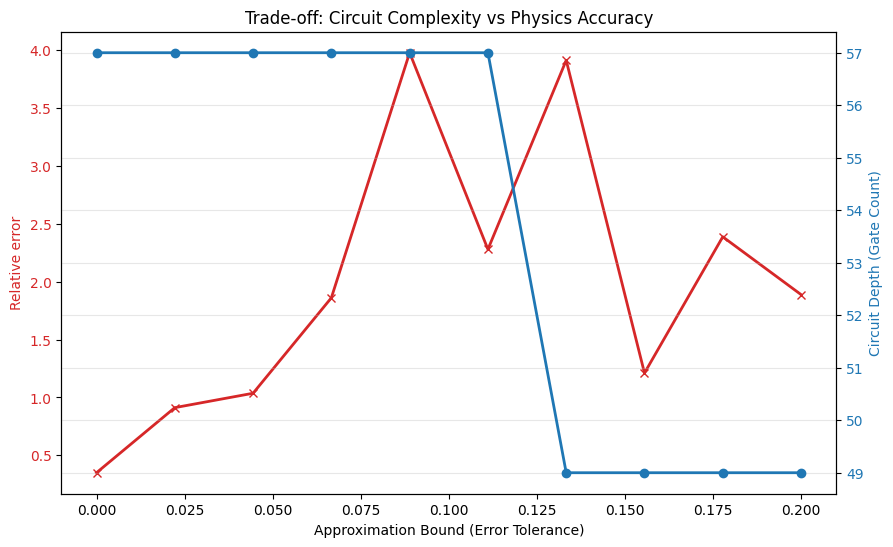

In [ ]:
from classiq.execution import ExecutionPreferences

# fixed time to evaluate HO
t_fixed = 1

# list of approximation bounds to test
test_bounds = list(np.linspace(0,0.2,10))

# for time = 1 the exact calculation:
# y(t) = cos(t) + sin(t)  (Position)
# y'(t) = cos(t) - sin(t) (Velocity)
pos = np.cos(t_fixed) + np.sin(t_fixed)
vel = np.cos(t_fixed) - np.sin(t_fixed)

# calculate normalized P.E. (Probability of State 0)
exact_pe_fraction = (pos**2) / (pos**2 + vel**2)

print(f'Starting accuracy analysis at t={t_fixed} ')
print(f'Exact value of potential energy fracton: {exact_pe_fraction: .4f}')
print('-'*55)
print(f"{'Bound':<6} | {'Depth':<8} | {'Measured P.E. Fraction':<15} | {'Relative Error':<8}")

# lists to store depth and error
depth_list = []
error_list = []

# loop over approximation bounds to study accuracy vs circuit complexity
for b in test_bounds:
  # HO quantum circuit at fixed time with changing approximation bound
  model = get_ho_circuit(t_fixed,b)

  # set execution preferences (number of measurement shots)
  preferences = ExecutionPreferences(num_shots=1000)
  model = set_execution_preferences(model,preferences)

  # synthesize circuit with Classiq engine to recieve quantum program
  qprog = synthesize(model)

  # get and store circuit depth (gate count after transpilation)
  depth = qprog.transpiled_circuit.depth
  depth_list.append(depth)

  # execute quantum program
  job = execute(qprog)

  # get measurement counts
  counts = job.result()[0].value.counts
  c000 = counts.get("000", 0)
  c001 = counts.get("001", 0)
  total = c000 + c001

  # compute measured potential energy fraction
  if total > 0:
    measured_pe_frac = c000 / total
  else: measured_pe_frac = 0

  # compute relative error compared to exact value
  relative_error = abs(measured_pe_frac - exact_pe_fraction) * 100 / exact_pe_fraction
  error_list.append(relative_error)

  # print results for current bound
  print(f"{b:.4f} | {depth:<8} | {measured_pe_frac:.4f}                 | {relative_error:.4f}")


fig, ax1 = plt.subplots(figsize=(10, 6))

# plot trade-off between circuit complexity and physics accuracy
color = 'tab:red'
ax1.set_xlabel('Approximation Bound (Error Tolerance)')
ax1.set_ylabel('Relative error', color=color)
ax1.plot(test_bounds, error_list, marker='x', color=color, label='Realtive Error', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# plot circuit depth on secondary y-axis to the right
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Circuit Depth (Gate Count)', color=color)
ax2.plot(test_bounds, depth_list, marker='o', color=color, label='Depth', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Trade-off: Circuit Complexity vs Physics Accuracy")
plt.grid(True, alpha=0.3)
plt.show()


## Using the Grouping Method we only need one ancilla.

In [ ]:
def get_ho1_circuit(time,error_bound):

  @qfunc
  def main(work_q: Output[QBit],anc_q: Output[QBit])->None:
    # allocate one work and one ancilla qubits
    allocate(1,work_q)
    allocate(1,anc_q)

    # initialize the work qubit to |+> state
    H(work_q)

    # the prababilities
    raw_probs = [np.cos(time), np.sin(time)]
    norm = sum(raw_probs)
    probs = [p/norm for p in raw_probs]

    # prepare the state i.e. encode
    inplace_prepare_state(probabilities=probs,bound=error_bound,target=anc_q)

    # apply I or IY depending on the ancilla
    control(anc_q, lambda: RY(-np.pi, work_q))

    # decode
    invert(lambda: inplace_prepare_state(probs,bound=error_bound,target=anc_q))

  return create_model(main)

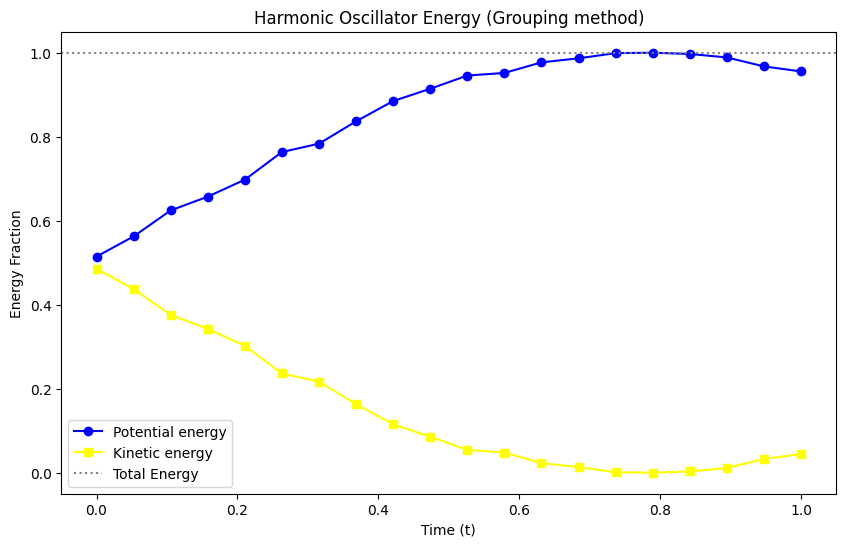

In [ ]:
# create an array of 20 time points from 0 to 1
ts=np.linspace(0,1,20)

# fixed bound parameter
fixed_bound = 0.01

# lists to store depth and error
counts_pe = []
counts_ke = []

# loop over each time point
for t in ts:
  # HO quantum circuit at time t with fixed bound
  model = get_ho1_circuit(t,fixed_bound)

  # synthesize circuit with Classiq engine to recieve quantum program
  qprog = synthesize(model)

  # execute quantum program
  job = execute(qprog)

  # get measurement counts
  counts = job.result()[0].value.counts
  c00 = counts.get("00", 0)
  c01 = counts.get("01", 0)

  # store counts
  counts_pe.append(c00)
  counts_ke.append(c01)

# compute total number of shots for each time point
total_shots = [p+k for (p,k) in zip(counts_pe,counts_ke)]

# compute probabilities for PE and KE while avoiding dividing by zero if total_shots == 0
prob_pe = [p/t if t > 0 else 0 for p, t in zip(counts_pe, total_shots)]
prob_ke = [k/t if t > 0 else 0 for k, t in zip(counts_ke, total_shots)]

# plot the energy fractions as a function of time
plt.figure(figsize=(10,6))
plt.plot(ts, prob_pe, 'o-', label='Potential energy', color='blue')
plt.plot(ts, prob_ke, 's-', label='Kinetic energy', color='yellow')
plt.axhline(y=1.0, color='gray', linestyle=':', label='Total Energy')

plt.title(f'Harmonic Oscillator Energy (Grouping method)')
plt.xlabel('Time (t)')
plt.ylabel('Energy Fraction')
plt.legend()
plt.show()

Starting accuracy analysis at t=1 
Exact value of potential energy fracton:  0.9546
-------------------------------------------------------
Bound  | Depth    | Measured P.E. Fraction | Relative Error
0.0000 | 5        | 0.9547                 | 0.0064
0.0222 | 5        | 0.9768                 | 2.3192
0.0444 | 5        | 0.9648                 | 1.0649
0.0667 | 5        | 0.9394                 | 1.5979
0.0889 | 5        | 0.9630                 | 0.8709
0.1111 | 5        | 0.9457                 | 0.9424
0.1333 | 5        | 0.9431                 | 1.2058
0.1556 | 5        | 0.9434                 | 1.1787
0.1778 | 5        | 0.9554                 | 0.0815
0.2000 | 5        | 0.9588                 | 0.4399


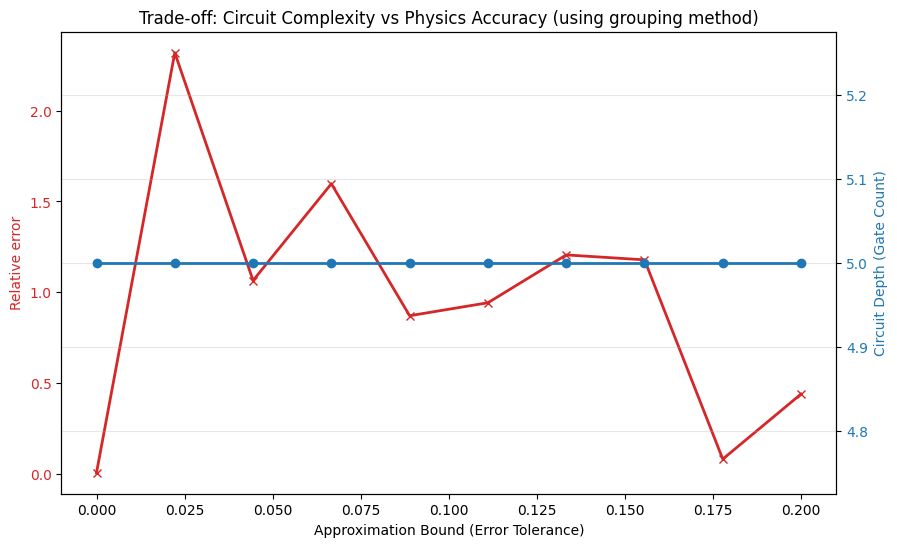

In [ ]:
t_fixed = 1
test_bounds = list(np.linspace(0,0.2,10))

# for time = 1 the exact calculation:
# y(t) = cos(t) + sin(t)  (Position)
# y'(t) = cos(t) - sin(t) (Velocity)
pos = np.cos(t_fixed) + np.sin(t_fixed)
vel = np.cos(t_fixed) - np.sin(t_fixed)

# calculate normalized P.E. (Probability of State 0)
exact_pe_fraction = (pos**2) / (pos**2 + vel**2)

print(f'Starting accuracy analysis at t={t_fixed} ')
print(f'Exact value of potential energy fracton: {exact_pe_fraction: .4f}')
print('-'*55)
print(f"{'Bound':<6} | {'Depth':<8} | {'Measured P.E. Fraction':<15} | {'Relative Error':<8}")

# lists to store circuit depth and error values for plotting
depth_list = []
error_list = []

# loop over approximation bounds to study accuracy vs circuit complexity
for b in test_bounds:
  # HO quantum circuit at fixed time with changing approximation bound
  model = get_ho1_circuit(t_fixed,b)

  # Set execution preferences (number of measurement shots)
  preferences = ExecutionPreferences(num_shots=1000)
  model = set_execution_preferences(model,preferences)

  # synthesize circuit with Classiq engine to recieve quantum program
  qprog = synthesize(model)

  # get and store circuit depth (gate count after transpilation)
  depth = qprog.transpiled_circuit.depth
  depth_list.append(depth)

  # execute quantum program
  job = execute(qprog)

  # get parsed measurement results (structured results by qubit name)
  parsed_counts = job.result()[0].value.parsed_counts

  # counters for potential and kinetic energy measurement shots
  pe_shots = 0
  ke_shots = 0

  # post-selection step
  for result in parsed_counts:
      # we only care about shots where the ancilla measured 0
      if result.state.get("anc_q") == 0:

          if result.state.get("work_q") == 0:
              pe_shots += result.shots

          elif result.state.get("work_q") == 1:
              ke_shots += result.shots

  # compute total valid shots after post-selection
  total = pe_shots + ke_shots

  # compute measured potential energy fraction
  if total > 0:
    measured_pe_frac = pe_shots / total
  else: measured_pe_frac = 0

  # compute relative error compared to exact analytical value
  relative_error = abs(measured_pe_frac - exact_pe_fraction) * 100 / exact_pe_fraction
  error_list.append(relative_error)

  # print results for the current approximation bound
  print(f"{b:.4f} | {depth:<8} | {measured_pe_frac:.4f}                 | {relative_error:.4f}")

# plot trade-off between accuracy and circuit complexity
fig, ax1 = plt.subplots(figsize=(10, 6))

# plot relative error on left axis
color = 'tab:red'
ax1.set_xlabel('Approximation Bound (Error Tolerance)')
ax1.set_ylabel('Relative error', color=color)
ax1.plot(test_bounds, error_list, marker='x', color=color, label='Realtive Error', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)


# plot circuit depth on right axis
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Circuit Depth (Gate Count)', color=color)
ax2.plot(test_bounds, depth_list, marker='o', color=color, label='Depth', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Trade-off: Circuit Complexity vs Physics Accuracy (using grouping method)")
plt.grid(True, alpha=0.3)
plt.show()

Notice that since we theoretically found the most efficient method using only a single ancilla, we don't find any change in the depth of the circuit with change in error bounds.

The fluctuation of the relative error is due to the noise or statistical fluctuations related to measurments in quantum computers.

Note: The circuit width remains fixed since we don't vary the k and only consider the cases where we need one and two ancillas.

## Advanced: Generalization for k
To fully analyze the relation between circuit depth and error with number of terms taken for the Taylor expansion, we implement the following circuit.

In [ ]:
def get_ho_circuit_k(time, error_bound, k):
    # determine how many ancilla qubits are needed to encode using Taylor series terms k+1 values
    num_ancillas = math.ceil(math.log2(k + 1))
    if num_ancillas == 0:
        num_ancillas = 1

    # calculate probabilities for the Taylor series: t^m / m!
    raw_probs =[(time**m) / math.factorial(m) for m in range(k + 1)]
    # make probability list length match 2^(num_ancillas)
    raw_probs += [0.0] * ((2**num_ancillas) - len(raw_probs))

    # normalize probabilities so that they sum to 1
    norm = sum(raw_probs)
    probs =[float(p / norm) for p in raw_probs]

    @qfunc
    def main(work_q: Output[QBit], anc_q: Output[QArray[QBit]]) -> None:
        # allocate one work and num_ancillas ancilla qubits
        allocate(1, work_q)
        allocate(num_ancillas, anc_q)

        H(work_q)
        inplace_prepare_state(probabilities=probs, bound=error_bound, target=anc_q)

        # apply controlled operations corresponding to each Taylor series term
        for m in range(1, k + 1):

            def apply_term(m_val=m):

                # binary representation of the Taylor index
                bin_str = format(m_val, f'0{num_ancillas}b')[::-1]

                # flip ancilla bits where needed so basis state activates the control
                def flip_bits():
                    for idx, bit in enumerate(bin_str):
                        if bit == '0':
                            X(anc_q[idx])

               # to determine which operator to apply based on m mod 4
                op_type = m_val % 4

                # iY
                if op_type == 1:
                    within_apply(flip_bits, lambda: control(anc_q, lambda: RY(-np.pi, work_q)))

                # -I (Compiler-Proof Version)
                elif op_type == 2:
                    def apply_minus_phase():
                        if num_ancillas == 1:
                            Z(anc_q[0])
                        else:
                            control(anc_q[0:num_ancillas-1], lambda: Z(anc_q[num_ancillas-1]))
                    within_apply(flip_bits, apply_minus_phase)

                # -iY
                elif op_type == 3:
                    within_apply(flip_bits, lambda: control(anc_q, lambda: RY(np.pi, work_q)))

            apply_term()

        invert(lambda: inplace_prepare_state(probabilities=probs, bound=error_bound, target=anc_q))

    return create_model(main)

Starting accuracy analysis at t=1
Exact value of potential energy fraction: 0.954649
---------------------------------------------------------------------------
Order (k)  | Depth    | Measured P.E. Fraction   | Absolute Error
1          | 5        | 1.000000                 | 0.045351
2          | 33       | 0.898888                 | 0.055761
3          | 55       | 0.942222                 | 0.012426
4          | 81       | 0.956241                 | 0.001592
5          | 104      | 0.960517                 | 0.005868
6          | 115      | 0.960489                 | 0.005840
7          | 138      | 0.949561                 | 0.005087


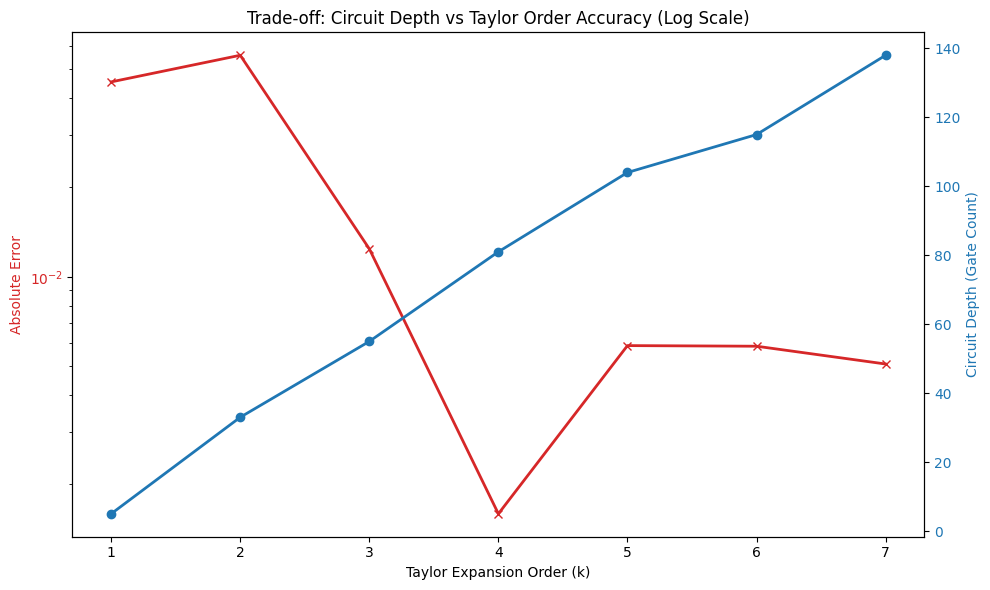

In [ ]:
t_fixed = 1

# Taylor expansion orders to test
test_ks = [1, 2, 3, 4, 5, 6, 7]

# set approximation bound to zero
fixed_bound = 0.0

# compute exact analytical solution for t_fixed = 1
pos = np.cos(t_fixed) + np.sin(t_fixed)
vel = np.cos(t_fixed) - np.sin(t_fixed)

# exact potential energy fraction
exact_pe_fraction = (pos**2) / (pos**2 + vel**2)

print(f'Starting accuracy analysis at t={t_fixed}')
print(f'Exact value of potential energy fraction: {exact_pe_fraction:.6f}')
print('-'*75)
print(f"{'Order (k)':<10} | {'Depth':<8} | {'Measured P.E. Fraction':<24} | {'Absolute Error':<8}")

# lists to store depth and error
depth_list = []
error_list = []

# helper function checks whether a measured value corresponds to |0⟩
def is_zero_state(val):
    if isinstance(val, (tuple, list)):
        return all(v == 0 for v in val)
    return val == 0 or val == 0.0

# loop over Taylor expansion order k
for k in test_ks:
    model = get_ho_circuit_k(t_fixed, fixed_bound, k)

    preferences = ExecutionPreferences(num_shots=10000)
    model = set_execution_preferences(model, preferences)

    qprog = synthesize(model)
    depth = qprog.transpiled_circuit.depth
    depth_list.append(depth)

    job = execute(qprog)
    parsed_counts = job.result()[0].value.parsed_counts

    pe_shots = 0
    ke_shots = 0

    for result in parsed_counts:
        anc_val = result.state.get("anc_q")
        work_val = result.state.get("work_q")

        # POST-SELECTION: Safely check if ancilla is all zeros
        if is_zero_state(anc_val):
            if is_zero_state(work_val):
                pe_shots += result.shots
            else:
                ke_shots += result.shots

    total = pe_shots + ke_shots
    measured_pe_frac = (pe_shots / total) if total > 0 else 0

    absolute_error = abs(measured_pe_frac - exact_pe_fraction)
    error_list.append(absolute_error)

    print(f"{k:<10} | {depth:<8} | {measured_pe_frac:<24.6f} | {absolute_error:.6f}")


# plot results
fig, ax1 = plt.subplots(figsize=(10, 6))

# plot error vs Taylor order
color = 'tab:red'
ax1.set_xlabel('Taylor Expansion Order (k)')
ax1.set_ylabel('Absolute Error', color=color)
ax1.plot(test_ks, error_list, marker='x', color=color, label='Absolute Error', linewidth=2)

# use log scale to highlight exponential error reduction
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor=color)

# plot circuit depth vs Taylor order
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Circuit Depth (Gate Count)', color=color)
ax2.plot(test_ks, depth_list, marker='o', color=color, label='Depth', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Trade-off: Circuit Depth vs Taylor Order Accuracy (Log Scale)")
plt.xticks(test_ks)
fig.tight_layout()
plt.show()

##Verdict:
Our grouping method utilized a single ancilla to solve the linear differential equation making it the most efficient approach.